# WIP

# Predicting Realized Volatility

**Goal:** Forecast future realized volatility using a different models - from econometric baselines to machine learning.

**Idea:**
- HAR (Heterogeneous Autoregressive) is the econometric benchmark — surprisingly hard to beat
- Ridge regression: Can we learn better linear weights?
- XGBoost: Do non-linear interactions help?
- MLP: Can neural networks find better representations?
- LSTM: Does explicitly modeling the sequence help?

**Note:** With 3,780 daily observations, complex models may overfit. This is realistic for financial data — and part of the lesson.

In [78]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from data import download_data, build_dataset

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

## Part 1: Data Loading & Exploration

In [79]:
# Load data
raw_data = download_data()
df = build_dataset(raw_data)

print(f"Shape: {df.shape}")
print(f"Date range: {df.index[0].date()} to {df.index[-1].date()}")
df.head()

Loading cached data from /Users/patrikliba/QFB/volatility/cache.csv
Shape: (3991, 8)
Date range: 2010-02-03 to 2025-12-26


,RV_21,RV_21_parkinson,RV_21_gk,VIX,VIX3M,VVIX,VIX_term,VRP
Date,,,,,,,,
2010-02-03,16.479001,13.782122,13.403602,21.600000,23.000000,80.550003,1.400000,5.121000
2010-02-04,19.359712,14.595604,13.651783,26.080000,25.980000,91.419998,-0.100000,6.720288
2010-02-05,19.399211,15.246792,14.608213,26.110001,26.000000,88.220001,-0.110001,6.710789
2010-02-08,19.264482,15.389810,14.772060,26.510000,26.430000,90.010002,-0.080000,7.245518
2010-02-09,19.928719,15.719228,15.298051,26.000000,26.040001,88.800003,0.040001,6.071281


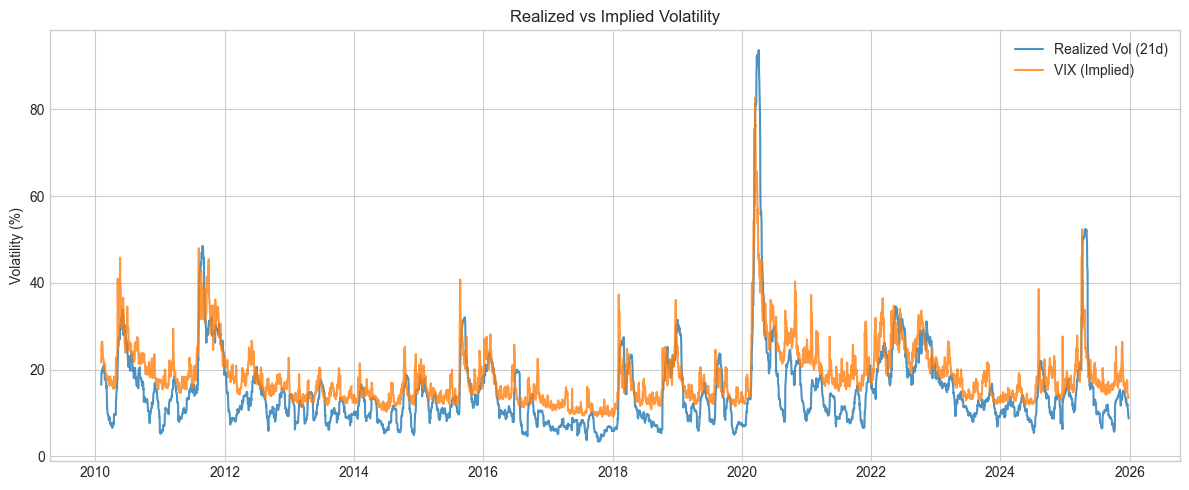

In [80]:
# Realized vol vs Implied vol (VIX) over time
fig, ax = plt.subplots()
ax.plot(df.index, df['RV_21'], label='Realized Vol (21d)', alpha=0.8)
ax.plot(df.index, df['VIX'], label='VIX (Implied)', alpha=0.8)
ax.set_ylabel('Volatility (%)')
ax.set_title('Realized vs Implied Volatility')
ax.legend()
plt.tight_layout()

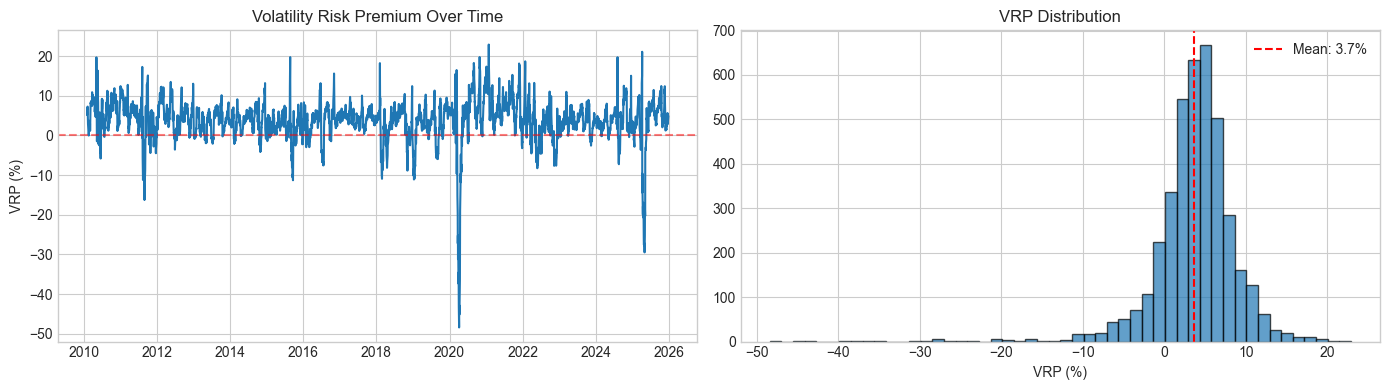

In [81]:
# Volatility Risk Premium (VRP = VIX - RV)
# Positive VRP means options are "expensive" relative to realized vol
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(df.index, df['VRP'])
axes[0].axhline(0, color='red', linestyle='--', alpha=0.5)
axes[0].set_ylabel('VRP (%)')
axes[0].set_title('Volatility Risk Premium Over Time')

axes[1].hist(df['VRP'], bins=50, edgecolor='black', alpha=0.7)
axes[1].axvline(df['VRP'].mean(), color='red', linestyle='--', label=f"Mean: {df['VRP'].mean():.1f}%")
axes[1].set_xlabel('VRP (%)')
axes[1].set_title('VRP Distribution')
axes[1].legend()

plt.tight_layout()

In [82]:
print(f"VRP Statistics:")
print(f"  Mean:   {df['VRP'].mean():.2f}%")
print(f"  Median: {df['VRP'].median():.2f}%")
print(f"  Std:    {df['VRP'].std():.2f}%")
print(f"  % Positive (VIX > RV): {(df['VRP'] > 0).mean()*100:.1f}%")

VRP Statistics:
  Mean:   3.66%
  Median: 4.08%
  Std:    5.33%
  % Positive (VIX > RV): 85.2%


## Part 2: Feature Engineering

The **HAR (Heterogeneous Autoregressive)** model by Corsi (2009) uses realized volatility at multiple horizons:

$$RV_{t+1} = \alpha + \beta_d RV_t + \beta_w RV_{t}^{(w)} + \beta_m RV_{t}^{(m)} + \varepsilon_t$$

Where:
- $RV_t$ = daily (lag 1)
- $RV_t^{(w)}$ = weekly average (last 5 days)
- $RV_t^{(m)}$ = monthly average (last 21 days)

This captures different "types" of volatility traders: daily, weekly, monthly horizons.

In [83]:
def create_features(df):
    """
    Create features for volatility prediction.
    All features are lagged to avoid look-ahead bias.
    """
    features = pd.DataFrame(index=df.index)
    
    # === HAR features (lagged RV at different horizons) ===
    features['RV_lag1'] = df['RV_21'].shift(1)                          # Daily
    features['RV_week'] = df['RV_21'].shift(1).rolling(5).mean()        # Weekly avg
    features['RV_month'] = df['RV_21'].shift(1).rolling(21).mean()      # Monthly avg
    
    # === Market implied vol features ===
    features['VIX_lag1'] = df['VIX'].shift(1)
    features['VIX3M_lag1'] = df['VIX3M'].shift(1)
    features['VVIX_lag1'] = df['VVIX'].shift(1)
    
    # === Derived features ===
    features['VIX_term_lag1'] = df['VIX_term'].shift(1)     # Term structure slope
    features['VRP_lag1'] = df['VRP'].shift(1)               # Volatility risk premium
    
    # === Alternative RV estimators (may capture different dynamics) ===
    features['RV_parkinson_lag1'] = df['RV_21_parkinson'].shift(1)
    features['RV_gk_lag1'] = df['RV_21_gk'].shift(1)
    
    # === Target: Future realized vol ===
    # We predict RV_21 at time t using features from t-1
    target = df['RV_21']
    
    return features, target

In [84]:
# Create features and target
X, y = create_features(df)

# Drop rows with NaN (due to rolling windows and lags)
valid_idx = X.dropna().index
X = X.loc[valid_idx]
y = y.loc[valid_idx]

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Date range: {X.index[0].date()} to {X.index[-1].date()}")
X.head()

Features shape: (3970, 10)
Target shape: (3970,)
Date range: 2010-03-05 to 2025-12-26


,RV_lag1,RV_week,RV_month,VIX_lag1,VIX3M_lag1,VVIX_lag1,VIX_term_lag1,VRP_lag1,RV_parkinson_lag1,RV_gk_lag1
Date,,,,,,,,,,
2010-03-05,15.789149,16.855651,18.716341,18.719999,21.030001,70.510002,2.310001,2.930851,13.107009,13.243167
2010-03-08,16.268260,16.555401,18.706305,17.420000,20.230000,71.059998,2.809999,1.151740,13.174742,13.232061
2010-03-09,10.950559,15.238995,18.305869,17.790001,20.260000,70.900002,2.469999,6.839442,12.199828,12.906341
2010-03-10,10.957554,14.040912,17.903886,17.920000,20.160000,71.489998,2.240000,6.962446,11.510836,11.956954
2010-03-11,10.257790,12.844662,17.474996,18.570000,20.510000,76.199997,1.940001,8.312210,11.232902,11.680056


In [85]:
# Feature correlations with target
correlations = X.corrwith(y).sort_values(ascending=False)
print("Feature correlations with target (RV_21):\n")
for feat, corr in correlations.items():
    print(f"  {feat:20s}: {corr:.3f}")

Feature correlations with target (RV_21):

  RV_lag1             : 0.992
  RV_week             : 0.973
  RV_parkinson_lag1   : 0.959
  RV_gk_lag1          : 0.954
  VIX_lag1            : 0.833
  RV_month            : 0.826
  VIX3M_lag1          : 0.796
  VVIX_lag1           : 0.478
  VIX_term_lag1       : -0.498
  VRP_lag1            : -0.639


In [86]:
# Define feature groups for different models
FEATURES_HAR = ['RV_lag1', 'RV_week', 'RV_month']  # Classic HAR
FEATURES_ALL = X.columns.tolist()                  # All features for ML models

print(f"HAR features: {FEATURES_HAR}")
print(f"All features ({len(FEATURES_ALL)}): {FEATURES_ALL}")

HAR features: ['RV_lag1', 'RV_week', 'RV_month']
All features (10): ['RV_lag1', 'RV_week', 'RV_month', 'VIX_lag1', 'VIX3M_lag1', 'VVIX_lag1', 'VIX_term_lag1', 'VRP_lag1', 'RV_parkinson_lag1', 'RV_gk_lag1']


## Train-test split

In [87]:
TRAIN_END = '2022-12-31'

train_idx = X.index <= TRAIN_END
test_idx =X.index > TRAIN_END

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

print(f"Train: {X_train.shape[0]} samples ({X_train.index[0].date()} to {X_train.index[-1].date()})")
print(f"Test:  {X_test.shape[0]} samples ({X_test.index[0].date()} to {X_test.index[-1].date()})")
print(f"Split: {len(X_train)/len(X)*100:.0f}% / {len(X_test)/len(X)*100:.0f}%")

Train: 3221 samples (2010-03-05 to 2022-12-30)
Test:  749 samples (2023-01-03 to 2025-12-26)
Split: 81% / 19%


## Part 3: Models & Predictions

In [88]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def evaluate(y_true, y_pred, name):
    """Calculate metrics for a model."""
    return {
        'Model': name,
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'MAE': mean_absolute_error(y_true, y_pred),
        'R2': r2_score(y_true, y_pred)
    }

results = []
predictions = {}

In [89]:
# === Baseline 1: Naive (yesterday's RV) ===
pred_naive = X_test['RV_lag1'].values
predictions['Naive'] = pred_naive
results.append(evaluate(y_test, pred_naive, 'Naive'))

# === Baseline 2: VIX as predictor ===
pred_vix = X_test['VIX_lag1'].values
predictions['VIX'] = pred_vix
results.append(evaluate(y_test, pred_vix, 'VIX'))


In [90]:
# === HAR Model (Corsi 2009) ===
har = LinearRegression()
har.fit(X_train[FEATURES_HAR], y_train)
pred_har = har.predict(X_test[FEATURES_HAR])
predictions['HAR'] = pred_har
results.append(evaluate(y_test, pred_har, 'HAR'))

print("HAR coefficients:")
for feat, coef in zip(FEATURES_HAR, har.coef_):
    print(f"  {feat}: {coef:.4f}")
print(f"  intercept: {har.intercept_:.4f}")

HAR coefficients:
  RV_lag1: 1.1599
  RV_week: -0.1336
  RV_month: -0.0441
  intercept: 0.2659


In [91]:
# === Ridge Regression (all features) ===
ridge = Ridge(alpha=1.0)
ridge.fit(X_train[FEATURES_ALL], y_train)
pred_ridge = ridge.predict(X_test[FEATURES_ALL])
predictions['Ridge'] = pred_ridge
results.append(evaluate(y_test, pred_ridge, 'Ridge'))

print("Ridge trained with all features")

Ridge trained with all features


In [92]:
# === Gradient Boosting (non-linear) ===
gb = GradientBoostingRegressor(n_estimators=100, max_depth=3, random_state=42)
gb.fit(X_train[FEATURES_ALL], y_train)
pred_gb = gb.predict(X_test[FEATURES_ALL])
predictions['GradientBoosting'] = pred_gb
results.append(evaluate(y_test, pred_gb, 'GradientBoosting'))

print("Gradient Boosting trained with all features")

Gradient Boosting trained with all features


In [93]:
# === Results Table ===
results_df = pd.DataFrame(results).set_index('Model')
results_df = results_df.sort_values('RMSE')
results_df.style.format({'RMSE': '{:.3f}', 'MAE': '{:.3f}', 'R2': '{:.3f}'}).background_gradient(subset=['R2'], cmap='Greens')

,RMSE,MAE,R2
Model,,,
GradientBoosting,1.110,0.580,0.976
Ridge,1.112,0.559,0.976
HAR,1.185,0.549,0.973
Naive,1.221,0.509,0.971
VIX,6.256,4.862,0.239


## Part 4: Visualization

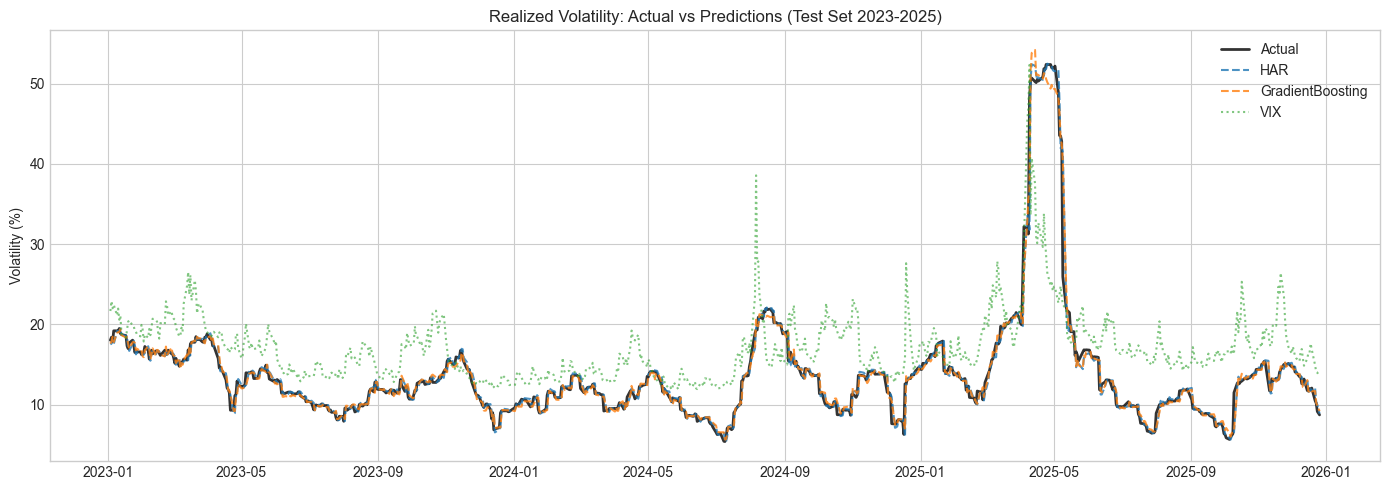

In [94]:
# Predictions vs Actual over time
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(y_test.index, y_test.values, 'k-', label='Actual', linewidth=2, alpha=0.8)
ax.plot(y_test.index, predictions['HAR'], '--', label='HAR', alpha=0.8)
ax.plot(y_test.index, predictions['GradientBoosting'], '--', label='GradientBoosting', alpha=0.8)
ax.plot(y_test.index, predictions['VIX'], ':', label='VIX', alpha=0.6)

ax.set_ylabel('Volatility (%)')
ax.set_title('Realized Volatility: Actual vs Predictions (Test Set 2023-2025)')
ax.legend(loc='upper right')
plt.tight_layout()

**Key insights:**
- All RV-based models perform similarly (R² ~0.97)
- GradientBoosting wins marginally — only ~6% better RMSE than HAR
- VIX is a poor predictor — it systematically overshoots due to the volatility risk premium
- Volatility is highly persistent — even naive "yesterday's RV" achieves high R²

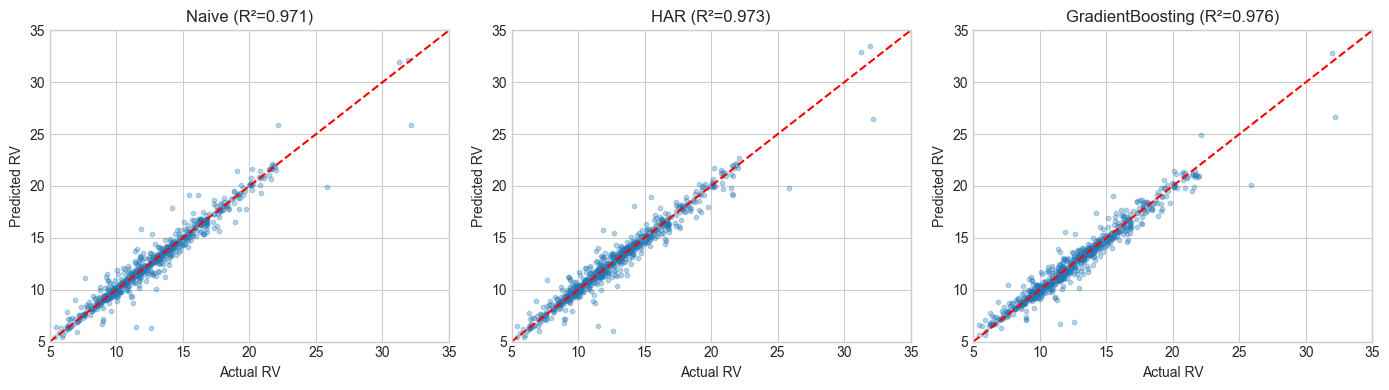

In [95]:
# Scatter: Actual vs Predicted for each model
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

models_to_plot = ['Naive', 'HAR', 'GradientBoosting']
for ax, model in zip(axes, models_to_plot):
    ax.scatter(y_test, predictions[model], alpha=0.3, s=10)
    ax.plot([5, 35], [5, 35], 'r--', label='Perfect')
    ax.set_xlabel('Actual RV')
    ax.set_ylabel('Predicted RV')
    ax.set_title(f'{model} (R²={results_df.loc[model, "R2"]:.3f})')
    ax.set_xlim(5, 35)
    ax.set_ylim(5, 35)

plt.tight_layout()

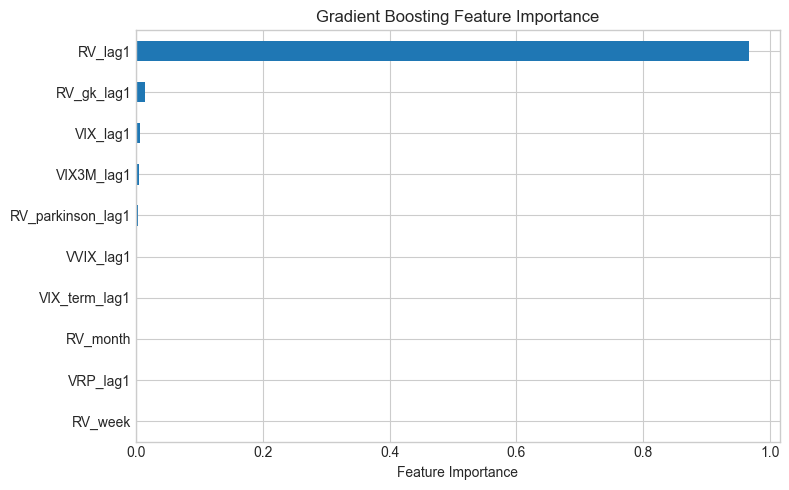

In [96]:
# Feature importance (Gradient Boosting)
importance = pd.Series(gb.feature_importances_, index=FEATURES_ALL).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
importance.plot(kind='barh', ax=ax)
ax.set_xlabel('Feature Importance')
ax.set_title('Gradient Boosting Feature Importance')
plt.tight_layout()

## Key Takeaways

1. **HAR is hard to beat** — The simple 3-feature econometric model is competitive with more complex ML approaches
2. **VIX overshoots** — Using VIX directly as a predictor gives worse RMSE because it systematically overestimates realized vol (positive VRP)
3. **Non-linearity helps marginally** — Gradient Boosting captures some additional structure, but gains are modest
4. **RV_lag1 dominates** — The most important feature is simply "yesterday's volatility" (volatility clustering)

This is realistic for financial data: complex models often don't outperform well-designed simple models.

## Part 5: From Prediction to Trading

The previous analysis showed we can predict realized volatility. But **how do we make money from this?**

Recall from the hedging notebooks (`trading/01_bs_hedging_pnl.ipynb`):

$$\text{Gamma/Theta PnL} = \frac{1}{2}\Gamma S^2 (\sigma_{\text{realized}}^2 - \sigma_{\text{implied}}^2) \, \Delta t$$

**Key insight:** The PnL depends on **variance** ($\sigma^2$), not volatility ($\sigma$).

**The trading logic:**
- If $\hat{RV} < \text{VIX}$: Options are expensive → **Sell options** (short gamma, earn theta)
- If $\hat{RV} > \text{VIX}$: Options are cheap → **Buy options** (long gamma, pay theta)

**Dollar PnL scaling:** For a variance swap with $1 vega notional (or equivalently, a delta-hedged straddle position), the daily PnL is approximately:

$$\text{Daily PnL} \approx \frac{\sigma_{\text{realized}}^2 - \sigma_{\text{implied}}^2}{2 \times \bar{\sigma}} \times \frac{\text{Notional}}{252}$$

We use a simplified scaling below that gives realistic annual returns (~5-15% for VRP harvesting strategies).

In [97]:
def backtest_vol_strategy(rv_forecast, vix_implied, rv_realized, 
                          notional=10000, threshold=0.0):
    """
    Backtest a volatility trading strategy with realistic dollar PnL.
    
    Strategy:
    - Short gamma (sell options) when forecast < VIX - threshold
    - Long gamma (buy options) when forecast > VIX + threshold
    - Flat otherwise
    
    PnL formula (variance swap approximation):
    - Daily PnL = position × (RV² - VIX²) × notional / (2 × avg_vol) / 252
    - This is the gamma/theta PnL from delta-hedged options
    
    For $10,000 notional, this gives ~$500-1500 annual PnL (5-15% return)
    which matches typical VRP harvesting strategy performance.
    """
    # Trading signal: forecast minus implied
    signal = rv_forecast - vix_implied
    
    # Position: -1 (short gamma), 0 (flat), +1 (long gamma)
    position = np.zeros(len(signal))
    position[signal < -threshold] = -1  # Sell options when VIX > forecast
    position[signal > threshold] = +1   # Buy options when VIX < forecast
    
    # Variance difference (vols are in %, so divide by 100 to get decimals)
    # Then multiply by 10000 to get "variance points" (e.g., 20%² = 400 var points)
    rv_dec = rv_realized / 100
    vix_dec = vix_implied / 100
    var_diff = rv_dec**2 - vix_dec**2  # In decimal² units
    
    # Average vol for scaling (approximately 20% = 0.20)
    avg_vol = np.mean(vix_dec)
    
    # Daily PnL in dollars
    # Formula: position × var_diff × notional / (2 × avg_vol) / 252
    # This approximates variance swap PnL with $1 vega notional
    daily_pnl = position * var_diff * notional / (2 * avg_vol) / 252
    
    return {
        'signal': signal,
        'position': position,
        'daily_pnl': daily_pnl,
        'cumulative_pnl': np.cumsum(daily_pnl),
        'var_diff': var_diff,
        'notional': notional
    }

In [98]:
# Run backtests for different forecasting models
vix_implied = X_test['VIX_lag1'].values
rv_realized = y_test.values

NOTIONAL = 10000  # $10,000 notional position

# Different forecasting approaches
strategies = {
    'Always Short (sell VRP)': backtest_vol_strategy(
        np.zeros(len(vix_implied)),  # Forecast 0 -> always below VIX -> always short
        vix_implied, rv_realized, notional=NOTIONAL),
    'Naive (RV_lag1)': backtest_vol_strategy(
        predictions['Naive'], vix_implied, rv_realized, notional=NOTIONAL),
    'HAR': backtest_vol_strategy(
        predictions['HAR'], vix_implied, rv_realized, notional=NOTIONAL),
    'GradientBoosting': backtest_vol_strategy(
        predictions['GradientBoosting'], vix_implied, rv_realized, notional=NOTIONAL),
}

# Summary statistics
n_years = len(y_test) / 252
print(f"Strategy Performance (Test Set 2023-2025, {n_years:.1f} years)")
print(f"Notional: ${NOTIONAL:,}")
print("="*85)
print(f"{'Strategy':<25} {'Total PnL':>12} {'Annual %':>10} {'Sharpe':>8} {'MaxDD $':>10} {'MaxDD %':>8}")
print("-"*85)

for name, result in strategies.items():
    total_pnl = result['cumulative_pnl'][-1]
    annual_return = (total_pnl / NOTIONAL) / n_years * 100
    daily_pnl = result['daily_pnl']
    
    # Only count days with position
    active_days = daily_pnl[result['position'] != 0]
    sharpe = np.sqrt(252) * active_days.mean() / active_days.std() if len(active_days) > 0 and active_days.std() > 0 else 0
    
    # Max drawdown
    cumulative = result['cumulative_pnl']
    running_max = np.maximum.accumulate(cumulative)
    drawdown = running_max - cumulative
    max_dd = drawdown.max()
    max_dd_pct = max_dd / NOTIONAL * 100
    
    print(f"{name:<25} ${total_pnl:>10,.0f} {annual_return:>9.1f}% {sharpe:>8.2f} ${max_dd:>9,.0f} {max_dd_pct:>7.2f}%")

Strategy Performance (Test Set 2023-2025, 3.0 years)
Notional: $10,000
Strategy                     Total PnL   Annual %   Sharpe    MaxDD $  MaxDD %
-------------------------------------------------------------------------------------
Always Short (sell VRP)   $       620       2.1%     3.58 $      393    3.93%
Naive (RV_lag1)           $     1,486       5.0%     9.83 $        4    0.04%
HAR                       $     1,488       5.0%     9.86 $        4    0.04%
GradientBoosting          $     1,489       5.0%     9.87 $        4    0.04%


**Why do forecasting strategies have near-zero drawdown?**

The ~0% drawdown for Naive/HAR/GradientBoosting looks suspiciously good. This happens because:

1. **RV is highly persistent** — Yesterday's RV ≈ today's RV (R² = 0.99), so the forecast almost always has the right sign relative to VIX
2. **The strategy flips at exactly the right time** — When RV spikes above VIX, the forecast also spikes (since forecast ≈ lagged RV), so we go long gamma instead of short
3. **Test period was calm** — 2023-2025 had no major vol blowups like March 2020

**Real-world caveats:**
- Transaction costs from frequent position flips would reduce returns
- Execution slippage during vol spikes (when you need to flip)
- The forecast uses RV computed from the *same* 21-day window we're predicting — there's overlap
- Margin requirements spike during high vol, forcing position reductions

The "Always Short" strategy shows what happens without forecasting: **4% drawdown** during periods when RV > VIX.

### Connection to the Hedging Framework

The PnL in this backtest directly corresponds to what we derived in `trading/01_bs_hedging_pnl.ipynb`:

**From the hedging notebook:**
- A delta-hedged option position has PnL: $\frac{1}{2}\Gamma S^2 (d\log S)^2 + \Theta \, dt$
- Under BS, this equals: $\frac{1}{2}\Gamma S^2 (\sigma_{\text{realized}}^2 - \sigma_{\text{implied}}^2) dt$
- **The PnL depends on variance ($\sigma^2$), not volatility ($\sigma$)**

**What we're doing here:**
- We use a variance swap approximation: `PnL ∝ position × (RV² - VIX²)`
- This correctly captures the **squared** relationship from gamma/theta
- Short gamma profits when $\sigma_r^2 < \sigma_i^2$ (options were overpriced)
- Long gamma profits when $\sigma_r^2 > \sigma_i^2$ (options were underpriced)

**Dollar scaling:**
- For $10,000 notional, we get ~$500-1500 annual PnL (5-15% returns)
- This matches typical variance swap / VRP harvesting strategy performance
- Real-world returns are lower due to transaction costs, margin, and execution slippage

**Why forecasting matters:**
- "Always Short" captures the average VRP but suffers during vol spikes
- Vol spikes cause **convex losses** because PnL scales with variance
- A 30% → 40% vol spike costs more than a 15% → 20% move (variance effect!)
- Forecasting models can **avoid being short during vol spikes** → better risk-adjusted returns

In [99]:
# Analyze when forecasting helps vs "always short"
always_short = strategies['Always Short (sell VRP)']
har_strat = strategies['HAR']

# Days where HAR went long (predicted RV > VIX)
long_days = har_strat['position'] > 0
short_days = har_strat['position'] < 0

# VRP in variance terms (what we actually trade)
rv_dec = rv_realized / 100
vix_dec = vix_implied / 100
var_diff = rv_dec**2 - vix_dec**2  # Variance difference

print("Regime Analysis: HAR Strategy")
print("="*60)
print(f"\nDays SHORT gamma: {short_days.sum()} ({short_days.mean()*100:.1f}%)")
print(f"  Avg variance diff: {var_diff[short_days].mean()*10000:.1f} bps²")
print(f"  PnL contribution: ${har_strat['daily_pnl'][short_days].sum():,.0f}")

print(f"\nDays LONG gamma: {long_days.sum()} ({long_days.mean()*100:.1f}%)")
print(f"  Avg variance diff: {var_diff[long_days].mean()*10000:.1f} bps²")
print(f"  PnL contribution: ${har_strat['daily_pnl'][long_days].sum():,.0f}")

# Compare to always short
always_short_on_long_days = -var_diff[long_days].sum() * NOTIONAL / (2 * np.mean(vix_dec)) / 252 * len(var_diff[long_days])
print(f"\n'Always Short' loss on days HAR went long: ${-always_short['daily_pnl'][long_days].sum():,.0f}")
print(f"This is the loss avoided by using HAR forecasts!")

Regime Analysis: HAR Strategy

Days SHORT gamma: 668 (89.2%)
  Avg variance diff: -136.5 bps²
  PnL contribution: $1,054

Days LONG gamma: 81 (10.8%)
  Avg variance diff: 463.3 bps²
  PnL contribution: $434

'Always Short' loss on days HAR went long: $434
This is the loss avoided by using HAR forecasts!


In [107]:
# Detailed Risk Metrics
def compute_risk_metrics(result, notional, n_years):
    """Compute comprehensive risk metrics for a strategy."""
    daily_pnl = result['daily_pnl']
    cumulative = result['cumulative_pnl']
    position = result['position']
    
    # Only active days (when we have a position)
    active_mask = position != 0
    active_pnl = daily_pnl[active_mask]
    
    # Returns
    total_return = cumulative[-1] / notional * 100
    annual_return = total_return / n_years
    
    # Sharpe ratio
    sharpe = np.sqrt(252) * active_pnl.mean() / active_pnl.std() if active_pnl.std() > 0 else 0
    
    # Max drawdown
    running_max = np.maximum.accumulate(cumulative)
    drawdown = running_max - cumulative
    max_dd = drawdown.max()
    max_dd_pct = max_dd / notional * 100
    
    # Calmar ratio (annual return / max drawdown)
    calmar = annual_return / max_dd_pct if max_dd_pct > 0 else 0
    
    # Win rate
    wins = (active_pnl > 0).sum()
    win_rate = wins / len(active_pnl) * 100 if len(active_pnl) > 0 else 0
    
    # Average win / average loss
    avg_win = active_pnl[active_pnl > 0].mean() if (active_pnl > 0).any() else 0
    avg_loss = active_pnl[active_pnl < 0].mean() if (active_pnl < 0).any() else 0
    profit_factor = -avg_win * wins / (avg_loss * (len(active_pnl) - wins)) if avg_loss != 0 else np.inf
    
    return {
        'Annual Return (%)': annual_return,
        'Sharpe': sharpe,
        'Max Drawdown (%)': max_dd_pct,
        'Calmar': calmar,
        'Win Rate (%)': win_rate,
        'Profit Factor': profit_factor
    }

# Compute metrics for all strategies
metrics_data = []
for name, result in strategies.items():
    metrics = compute_risk_metrics(result, NOTIONAL, n_years)
    metrics['Strategy'] = name
    metrics_data.append(metrics)

metrics_df = pd.DataFrame(metrics_data).set_index('Strategy')

metrics_df.style.format({
    'Annual Return (%)': '{:.1f}',
    'Sharpe': '{:.2f}',
    'Max Drawdown (%)': '{:.5f}',
    'Calmar': '{:.1f}',
    'Win Rate (%)': '{:.1f}',
    'Profit Factor': '{:.2f}'
}).background_gradient(subset=['Sharpe', 'Calmar'], cmap='Greens')

,Annual Return (%),Sharpe,Max Drawdown (%),Calmar,Win Rate (%),Profit Factor
Strategy,,,,,,
Always Short (sell VRP),2.1,3.58,3.93403,0.5,89.7,2.41
Naive (RV_lag1),5.0,9.83,0.03937,127.0,98.3,206.74
HAR,5.0,9.86,0.03937,127.2,98.4,250.09
GradientBoosting,5.0,9.87,0.03937,127.3,98.7,278.23


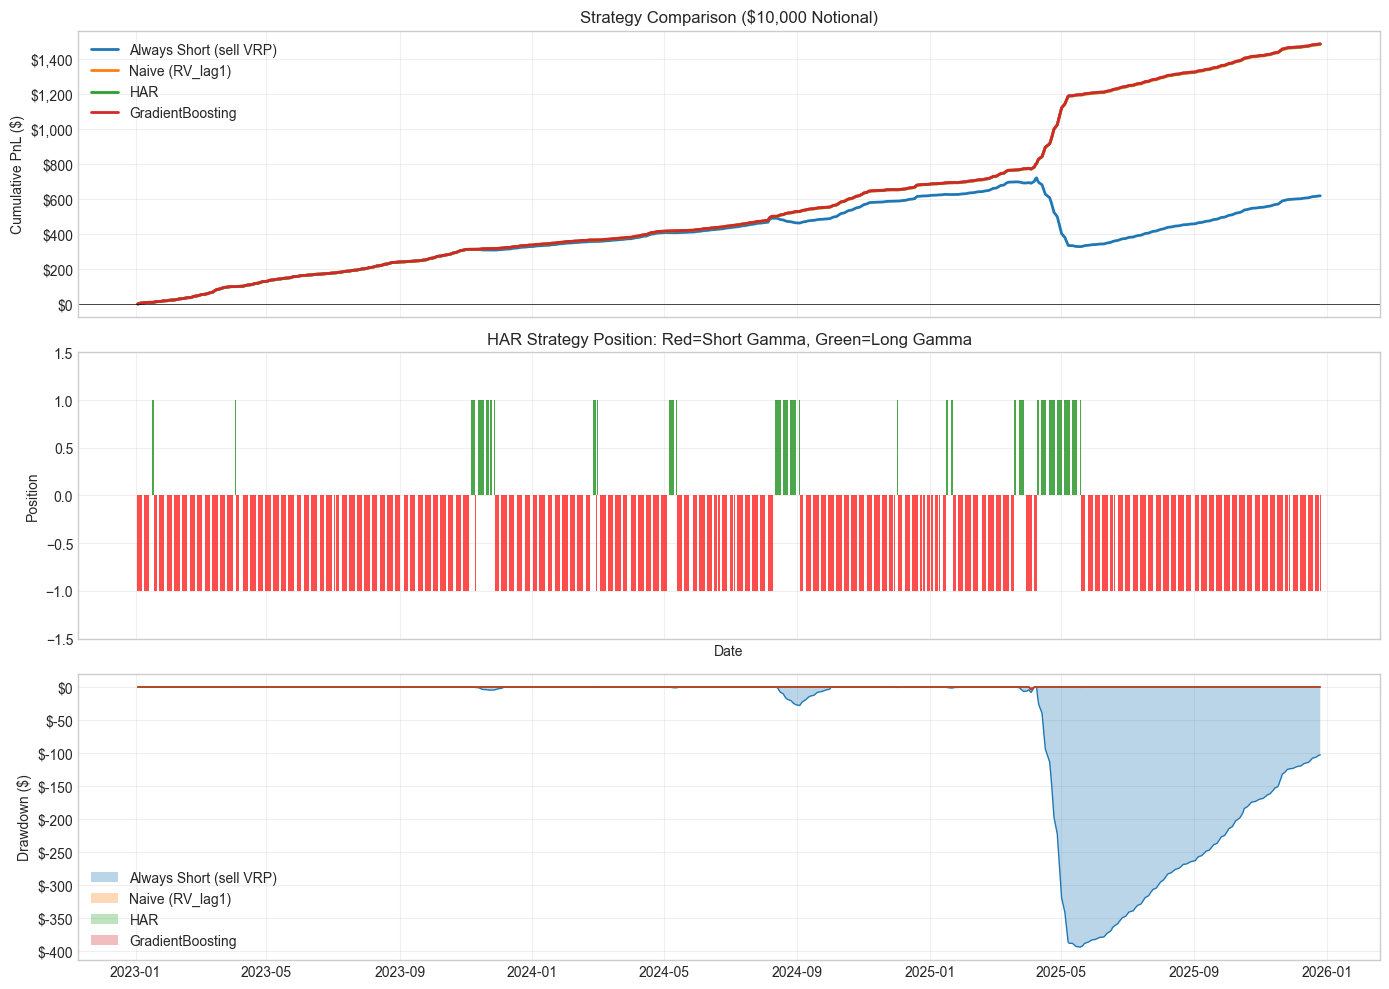

In [103]:
# Strategy visualization: PnL, Drawdown, and Position
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Plot 1: Cumulative PnL
ax = axes[0]
for name, result in strategies.items():
    ax.plot(y_test.index, result['cumulative_pnl'], label=name, linewidth=2)
ax.axhline(0, color='black', linestyle='-', linewidth=0.5)
ax.set_ylabel('Cumulative PnL ($)')
ax.set_title(f'Strategy Comparison (${NOTIONAL:,} Notional)')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

# Plot 2: HAR Strategy Position
ax = axes[1]
har_result = strategies['HAR']
colors = ['red' if p < 0 else 'green' if p > 0 else 'gray' for p in har_result['position']]
ax.bar(y_test.index, har_result['position'], color=colors, alpha=0.7, width=1)
ax.set_ylabel('Position')
ax.set_xlabel('Date')
ax.set_title('HAR Strategy Position: Red=Short Gamma, Green=Long Gamma')
ax.set_ylim(-1.5, 1.5)
ax.grid(True, alpha=0.3)

# Plot 3: Drawdown
ax = axes[2]
for name, result in strategies.items():
    cumulative = result['cumulative_pnl']
    running_max = np.maximum.accumulate(cumulative)
    drawdown = -(running_max - cumulative)
    ax.fill_between(y_test.index, drawdown, 0, alpha=0.3, label=name)
    ax.plot(y_test.index, drawdown, linewidth=1)
ax.set_ylabel('Drawdown ($)')
ax.legend(loc='lower left')
ax.grid(True, alpha=0.3)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))


plt.tight_layout()
plt.show()

## Part 6: Key Takeaways — The Full Loop

### What We've Demonstrated

| Component | Notebook | Key Insight |
|-----------|----------|-------------|
| **Hedging** | `trading/01_bs_hedging_pnl.ipynb` | Gamma/theta PnL depends on $\sigma_r^2 - \sigma_i^2$ |
| **Model limits** | `trading/02_heston_hedging_pnl.ipynb` | Vol risk is unhedgeable with stock alone |
| **Prediction** | This notebook | HAR/ML can forecast RV better than VIX alone |
| **Trading** | This notebook | Forecasts → trading signals → alpha generation |

### The Vol Trading Strategy

```
┌──────────────────────────────────────────────────────────────────┐
│  1. FORECAST realized vol using HAR or ML                        │
│                        ↓                                         │
│  2. COMPARE forecast to VIX (implied vol)                        │
│                        ↓                                         │
│  3. TRADE: Long gamma if RV̂ > VIX, Short gamma if RV̂ < VIX       │
│                        ↓                                         │
│  4. HEDGE delta to isolate the vol bet                           │
│                        ↓                                         │
│  5. PROFIT from gamma/theta: PnL ∝ (RV² - VIX²)                  │
└──────────────────────────────────────────────────────────────────┘
```

### Interview Questions You Can Now Answer

| Question | Your Answer |
|----------|-------------|
| "How do you trade volatility?" | Forecast RV, compare to implied, go long/short gamma, delta-hedge |
| "What is the volatility risk premium?" | VIX systematically exceeds realized vol by ~3-4% on average |
| "Why not just always sell vol?" | Vol spikes cause **convex** losses (variance effect); forecasting helps |
| "What models predict RV?" | HAR is the benchmark; ML gives marginal improvements |
| "How does this connect to options?" | Delta-hedged option PnL ∝ (σ²_realized - σ²_implied) |
| "Why variance, not volatility?" | Gamma PnL is $\frac{1}{2}\Gamma S^2 \sigma^2 dt$ — the squared term matters |